## DOCI Molecular Analysis

In [12]:
from src.molecular_doci import (
    doci_problem,
    to_doci_energy,
    lih,
    doci_ground_energy,
    fci_benchmarks,
)
from src.gadget import *

problem, c = doci_problem(
    lih(1), flip_sign=True, center_eps=True, orbitals="rhf", basis="4-31G"
)  # H' = -H_DOCI
drive = fit_drive(problem.g1, n_restarts=50, cap=4.0, use_c=False)
Enc = ParticleConservationEncoding(problem)
G = GadgetHamiltonian(
    problem, Enc, drive, GadgetParameters(gamma=200, self_energy="exact", use_c=False)
)

E, U = G.total().eigenstates()  # your qutip path works in your env
k = problem.dim - 1  # molecular GS = TOP state of the code block
print(to_doci_energy(E[k] * 200, c))  # Ha, compare with doci_ground_energy(c)

/home/ecosta/Gadget4NSMForQuantumSimulators/src/gadget/hamiltonian.py:235: RuntimeWarning: exact theta_1 is derived for one particle per constrained register; falling back to the uniform shift for the second-quantized encoding with N_tot > 1.
  warnings.warn(


-7.878361321994596


#### Wavefunction of the DOCI Hamiltonian

-7.87775906385879 -7.877759063858792


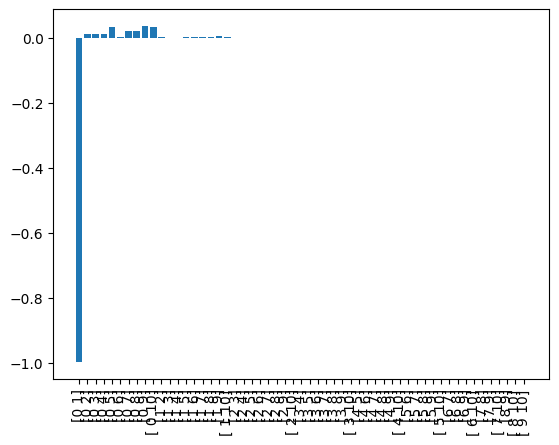

In [14]:
import numpy as np
import matplotlib.pyplot as plt

w, v = problem.exact_spectrum()
psi_gs = v[:, -1]
E_gs = to_doci_energy(w[-1], c)  # c = second return of doci_problem
# same as: -w[-1] + c["energy_map"]["offset"]
print(E_gs, doci_ground_energy(c))  # both in Ha, must agree
HBB = problem.hardcore_basis()

tupl = [np.nonzero(x)[0] for a, x in enumerate(HBB.basis)]

plt.bar(np.arange(HBB.basis.shape[0]), psi_gs)
plt.xticks(np.arange(HBB.basis.shape[0]), tupl, rotation=90)
plt.show()

Comparison with the gadget Wavefunction

/home/ecosta/Gadget4NSMForQuantumSimulators/src/gadget/hamiltonian.py:235: RuntimeWarning: exact theta_1 is derived for one particle per constrained register; falling back to the uniform shift for the second-quantized encoding with N_tot > 1.
  warnings.warn(


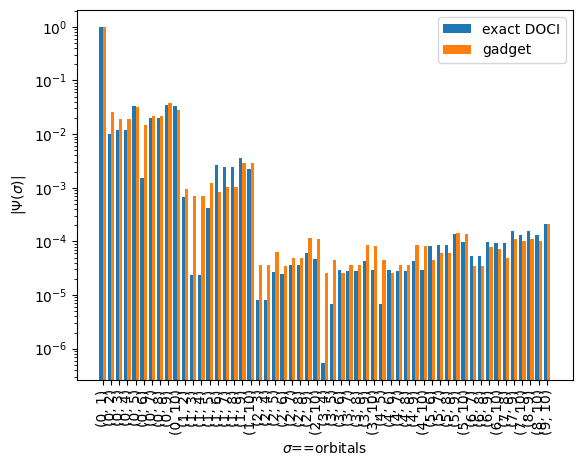

leakage 2.759784135664134e-06  F 0.9994001453626249


In [17]:
L, _ = G.linear_operator()  # or: E, U = G.total().eigenstates()
E, U = np.linalg.eigh(L.matmat(np.eye(L.shape[0])))
k = problem.dim - 1  # top of code block = molecular GS (flipped)
psi_gadget = U[:, k]

amp = Enc.project(psi_gadget).real  # gadget amplitudes on the logical basis
w, v = problem.exact_spectrum()
psi_ex = v[:, -1] / np.linalg.norm(v[:, -1])  # exact molecular GS
amp *= np.sign(amp @ psi_ex)  # fix global sign

labels = [str(cfg) for cfg in problem.logical_basis()]
x = np.arange(len(labels))
plt.bar(x - 0.2, np.abs(psi_ex), 0.4, label="exact DOCI")
plt.bar(x + 0.2, np.abs(amp), 0.4, label="gadget")
plt.xticks(x, labels, rotation=90)
plt.legend()
plt.xlabel(r"$\sigma$==orbitals")
plt.ylabel(r"$|\Psi(\sigma)|$")
plt.semilogy()
plt.show()
print(
    "leakage",
    Enc.leakage(psi_gadget),
    " F",
    Enc.fidelity(psi_gadget, psi_ex, normalize=False),
)

#### Analysis for different $\gamma$

In [ ]:
from src.molecular_doci import (
    doci_problem,
    to_doci_energy,
    lih,
    doci_ground_energy,
    fci_benchmarks,
)
from src.gadget import *

gammas = np.linspace(0.1, 50, 20)
rs = np.linspace(0.1, 4, 20)

gadget_energies = np.zeros((20, 20))
gadget_fidelity = np.zeros((20, 20))

energy_doci = []
energy_fci = []


for a, r in enumerate(rs):
    for b, gamma in enumerate(gammas):

        problem, c = doci_problem(
            lih(r), flip_sign=True, center_eps=True, basis="4-31G"
        )  # H' = -H_DOCI
        drive = fit_drive(problem.g1, n_restarts=50, cap=4.0, use_c=False)
        Enc = ParticleConservationEncoding(problem)
        G = GadgetHamiltonian(
            problem,
            Enc,
            drive,
            GadgetParameters(gamma=gamma, self_energy="exact", use_c=False),
        )

        E, U = G.total().eigenstates()  # your qutip path works in your env
        k = problem.dim - 1  # molecular GS = TOP state of the code block
        print(to_doci_energy(E[k] * gamma, c))  # Ha, compare with doci_ground_energy(c)
        gadget_energies[a, b] = to_doci_energy(E[k] * gamma, c)
        L, _ = G.linear_operator()  # or: E, U = G.total().eigenstates()
        E, U = np.linalg.eigh(L.matmat(np.eye(L.shape[0])))
        k = problem.dim - 1  # top of code block = molecular GS (flipped)
        psi_gadget = U[:, k]

        amp = Enc.project(psi_gadget).real  # gadget amplitudes on the logical basis
        w, v = problem.exact_spectrum()
        psi_ex = v[:, -1]  # exact molecular GS
        amp *= np.sign(amp @ psi_ex)  # fix global sign

        if b == 5:
            plt.title(f"gamma={gamma} r={r}")
            labels = [str(cfg) for cfg in problem.logical_basis()]
            x = np.arange(len(labels))
            plt.bar(x - 0.2, np.abs(psi_ex), 0.4, label="exact DOCI")
            plt.bar(x + 0.2, np.abs(amp), 0.4, label="gadget")
            plt.xticks(x, labels, rotation=90)
            plt.legend()
            plt.xlabel(r"$\sigma$==orbitals")
            plt.ylabel(r"$|\Psi(\sigma)|$")
            plt.semilogy()
            plt.show()
        print(
            "leakage",
            Enc.leakage(psi_gadget),
            " F",
            Enc.fidelity(psi_gadget, psi_ex, normalize=False),
        )
        gadget_fidelity[a, b] = Enc.fidelity(psi_gadget, psi_ex, normalize=False)
    b = fci_benchmarks(c)  # c = second return of doci_problem(...)
    energy_doci.append(doci_ground_energy(c))
    energy_fci.append(b["e_fci"])
    print("RHF   :", b["e_rhf"])
    print("CASCI :", b["e_casci"])  # FCI inside the SAME active space as DOCI
    print("FCI   :", b["e_fci"])

(20, 20)


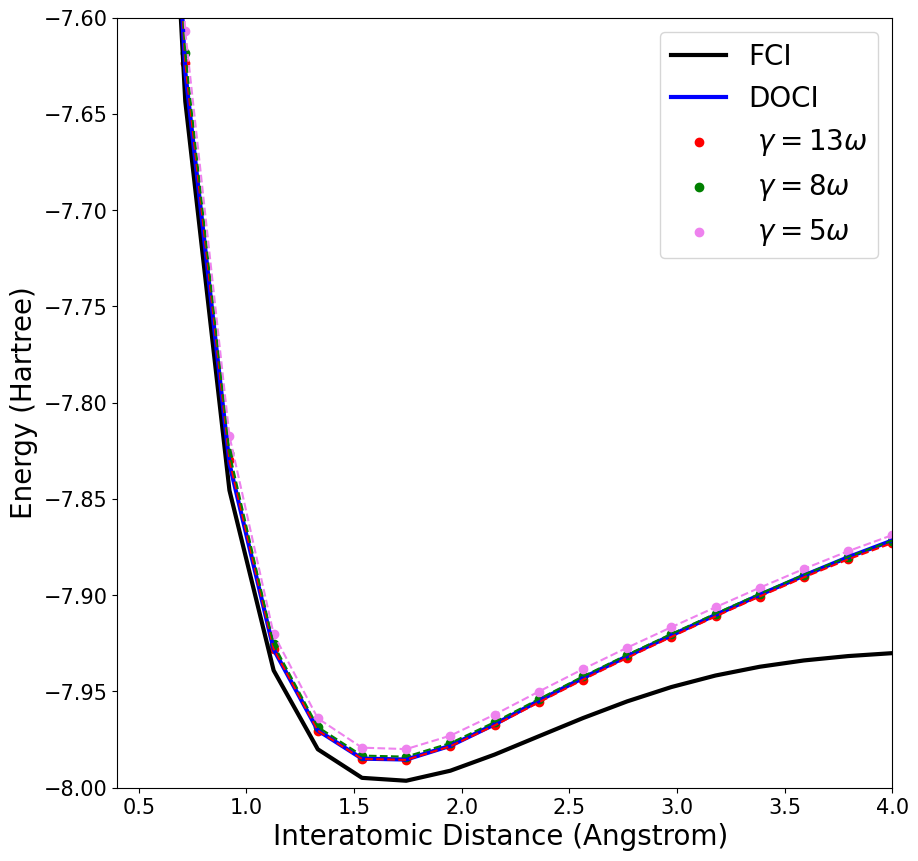

In [105]:
indices = [-15, -17, -18]
plt.figure(figsize=(10, 10))
print(gadget_energies.shape)
colors = ["red", "green", "violet"]
plt.plot(rs, energy_fci, label="FCI", color="black", linewidth=3)
plt.plot(
    rs,
    energy_doci,
    label="DOCI",
    color="blue",
    linewidth=3,
)
for i, idx in enumerate(indices):
    plt.plot(rs, gadget_energies[:, idx], linestyle="--", color=colors[i])
    plt.scatter(
        rs,
        gadget_energies[:, idx],
        label=rf" $\gamma=${gammas[idx]:.0f}$\omega$",
        color=colors[i],
    )
plt.ylim([-8, -7.6])
plt.xlim([0.4, 4])
plt.legend(fontsize=20)
plt.ylabel("Energy (Hartree)", fontsize=20)
plt.xlabel("Interatomic Distance (Angstrom) ", fontsize=20)
plt.tick_params(labelsize=15)
plt.show()

### Error

[0.1        0.30526316 0.51052632 0.71578947 0.92105263 1.12631579
 1.33157895 1.53684211 1.74210526 1.94736842 2.15263158 2.35789474
 2.56315789 2.76842105 2.97368421 3.17894737 3.38421053 3.58947368
 3.79473684 4.        ] [ 1.63279756e-02  1.87921971e-02  4.99848425e-03  1.84692626e-03
 -5.55607226e-05 -8.81203063e-04 -1.01395044e-03 -1.02895997e-03
 -1.02425959e-03 -1.08966160e-03 -1.38358436e-03 -1.67218157e-03
 -1.71241242e-03 -1.64760611e-03 -1.56516452e-03 -1.51328963e-03
 -1.52068416e-03 -1.60019331e-03 -1.74902741e-03 -1.94384119e-03]


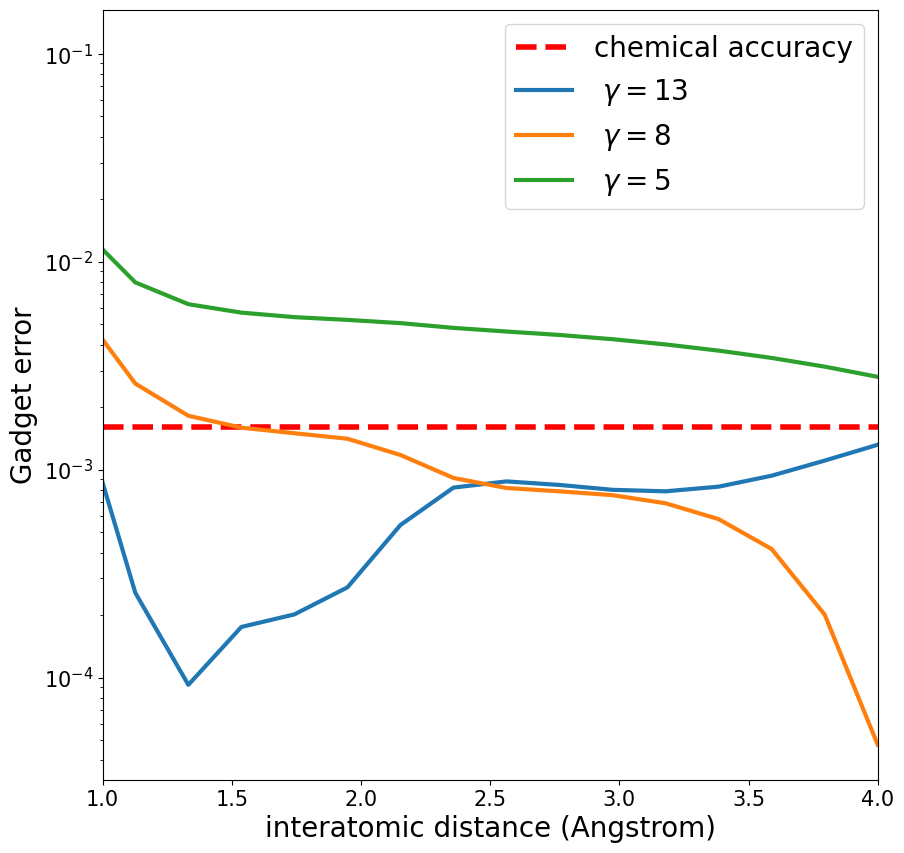

In [113]:
plt.figure(figsize=(10, 10))
plt.axhline(0.0016, label="chemical accuracy", color="red", linestyle="--", linewidth=4)

for idx in indices:
    plt.plot(
        rs,
        np.abs(-1 * np.asarray(energy_doci) + np.asarray(gadget_energies[:, idx])),
        label=rf" $\gamma = {gammas[idx]:.0f}$",
        linewidth=3,
    )

print(rs, -1 * np.asarray(energy_doci) + np.asarray(gadget_energies[:, -1]))

plt.semilogy()
plt.xlim([1, 4])
plt.ylabel("Gadget error", fontsize=20)
plt.xlabel("interatomic distance (Angstrom)", fontsize=20)
# plt.ylim([10**-6, 0.1])
plt.legend(fontsize=20)
plt.tick_params(labelsize=15)
plt.show()

#### Fidelities

(20, 20)


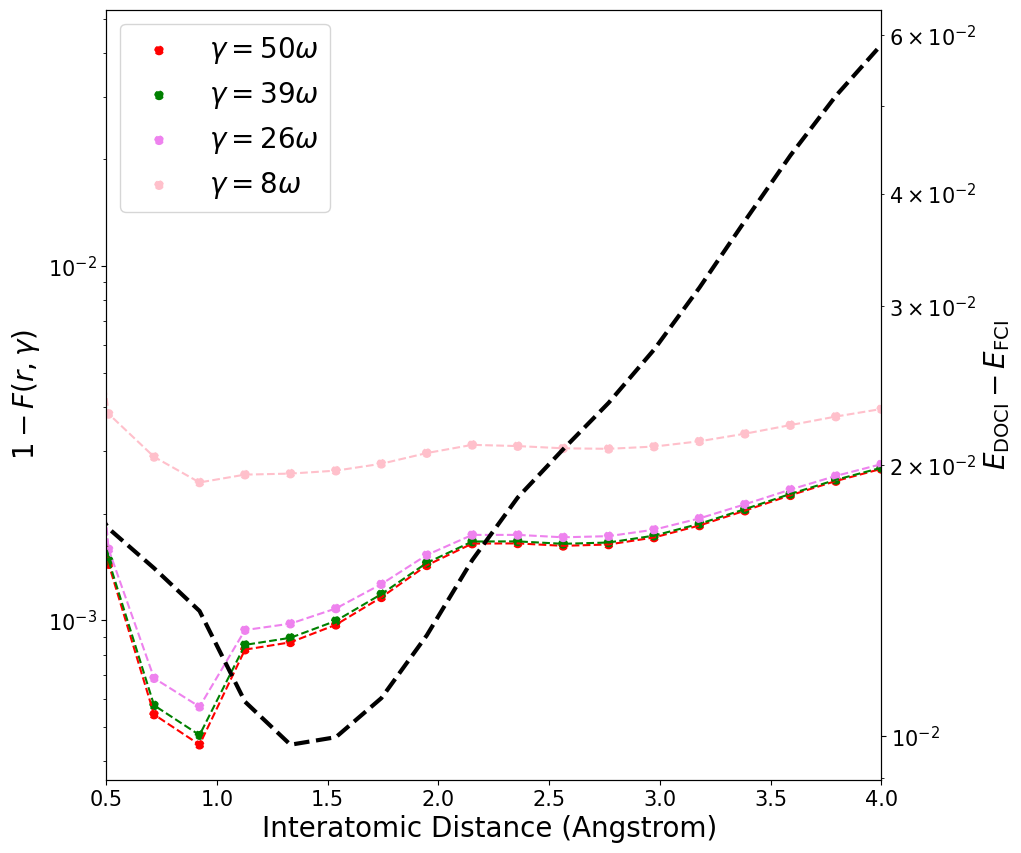

In [114]:
indices = [-1, -5, -10, -17]
print(gadget_fidelity.shape)
colors = ["red", "green", "violet", "pink"]
fig, ax = plt.subplots(figsize=(10, 10))

ax_twin = ax.twinx()


for i, idx in enumerate(indices):
    ax.plot(rs, 1 - gadget_fidelity[:, idx], linestyle="--", color=colors[i])
    ax.scatter(
        rs,
        1 - gadget_fidelity[:, idx],
        linestyle="--",
        color=colors[i],
        label=rf"$\gamma=${gammas[idx]:.0f}$\omega$",
    )

ax_twin.plot(
    rs,
    np.abs(np.asarray(energy_doci) - np.asarray(energy_fci)),
    color="black",
    linestyle="--",
    linewidth=3,
)
ax.tick_params(labelsize=15)
ax_twin.tick_params(labelsize=15, which="minor")
ax_twin.tick_params(labelsize=15, which="major")


ax.legend(fontsize=20, loc="upper left")
plt.xlim([0.5, 4])
ax.semilogy()
ax_twin.semilogy()
ax.set_ylabel(r"$1-F(r,\gamma)$", fontsize=20)
ax.set_xlabel("Interatomic Distance (Angstrom) ", fontsize=20)
ax_twin.set_ylabel(r"$E_{\text{DOCI}} - E_{\text{FCI}}$", fontsize=20)
plt.show()

### First Quantization Encoding